In [ ]:
import os
import sys
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [2]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])
OUTDIR = os.path.join(parent_dir,'mixture_outputs_hyper')
PLOTDIR = os.path.join(parent_dir,'plots/mixture')
if not os.path.exists(PLOTDIR):
    os.makedirs(PLOTDIR)

PATTERN = "coverage_seed_*.pkl"
files = sorted(glob.glob(os.path.join(OUTDIR, PATTERN)))

# Coverage across grid of $(\gamma, \lambda)$

In [3]:
alpha = 0.1
target_cov = 1 - alpha

dfs = [pd.read_pickle(f) for f in files]
df = pd.concat(dfs, ignore_index=True)
df["lambda"] = df["lambda"].astype(float)
df["gamma"] = df["gamma"].astype(float)

grid_marg = df[(df["method"] == "grid") & (df["shift_type"] == "Marginal")].copy()

agg_marg = (
    grid_marg
    .groupby(["lambda", "gamma"], as_index=False)
    .agg(
        mean_cov=("coverage", "mean"),
        sd_cov=("coverage", "std"),
        mean_cutoff=("cutoff", "mean"),
        sd_cutoff=("cutoff", "std"),
        n=("coverage", "size"),
    )
)

cov_pivot = agg_marg.pivot(index="lambda", columns="gamma", values="mean_cov")

cv_points_split = df[
    (df["method"] == "cv_split") &
    (df["shift_type"] == "Marginal")
][["seed", "lambda", "gamma"]].drop_duplicates()

cv_points_full = df[
    (df["method"] == "cv_full") &
    (df["shift_type"] == "Marginal")
][["seed", "lambda", "gamma"]].drop_duplicates()

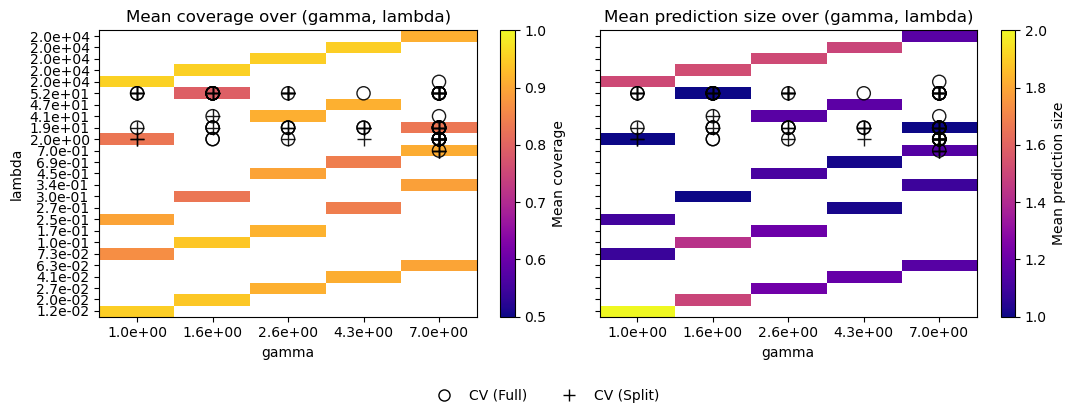

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

# ---------- Left: mean coverage ----------
ax = axes[0]

im1 = ax.imshow(
    cov_pivot.values,
    origin="lower",
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)

ax.set_xticks(np.arange(len(cov_pivot.columns)))
ax.set_xticklabels([f"{g:.1e}" for g in cov_pivot.columns])
ax.set_yticks(np.arange(len(cov_pivot.index)))
ax.set_yticklabels([f"{l:.1e}" for l in cov_pivot.index])

ax.set_xlabel("gamma")
ax.set_ylabel("lambda")
ax.set_title("Mean coverage over (gamma, lambda)")

im1.set_cmap(plt.cm.plasma)
cbar1 = fig.colorbar(im1, ax=ax)
cbar1.set_label("Mean coverage")

cs1 = ax.contour(
    cov_pivot.values,
    levels=[target_cov],
    colors="white",
    linewidths=1.5,
)
ax.clabel(cs1, fmt={target_cov: f"{target_cov:.2f}"})


# ---------- Right: mean prediction size ----------
cut_pivot = agg_marg.pivot(index="lambda", columns="gamma", values="mean_cutoff")
ax2 = axes[1]

im2 = ax2.imshow(
    cut_pivot.values,
    origin="lower",
    aspect="auto",
    vmin=1,
    vmax=2
)

ax2.set_xticks(np.arange(len(cov_pivot.columns)))
ax2.set_xticklabels([f"{g:.1e}" for g in cov_pivot.columns])
ax2.set_yticks(np.arange(len(cov_pivot.index)))
ax2.set_yticklabels([f"{l:.1e}" for l in cov_pivot.index])

ax2.set_xlabel("gamma")
ax2.set_title("Mean prediction size over (gamma, lambda)")

im2.set_cmap(plt.cm.plasma)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("Mean prediction size")

cs2 = ax2.contour(
    cov_pivot.values,
    levels=[target_cov],
    colors="white",
    linewidths=1.5,
)
ax2.clabel(cs2, fmt={target_cov: f"{target_cov:.2f}"})

for ax in axes:
    for _, row in cv_points_full.iterrows():
        lam_cv = row["lambda"]
        gam_cv = row["gamma"]

        y_idx = int(np.argmin(np.abs(cut_pivot.index.values - lam_cv)))
        x_idx = int(np.argmin(np.abs(cut_pivot.columns.values - gam_cv)))

        ax.scatter(
            x_idx, y_idx,
            marker="o",
            facecolors="none",
            edgecolors="k",
            s=90,          
            linewidths=1,  
            alpha=0.9,
        )

for ax in axes:
    for _, row in cv_points_split.iterrows():
        lam_cv = row["lambda"]
        gam_cv = row["gamma"]

        y_idx = int(np.argmin(np.abs(cut_pivot.index.values - lam_cv)))
        x_idx = int(np.argmin(np.abs(cut_pivot.columns.values - gam_cv)))

        ax.scatter(
            x_idx, y_idx,
            marker="+",
            color="k",    
            s=90,
            linewidths=1, 
            alpha=0.9,
        )

legend_elements = [
    Line2D([0], [0], marker="o", linestyle="None",
           markerfacecolor="none", markeredgecolor="k",
           markersize=8, label="CV (Full)"),
    Line2D([0], [0], marker="+", linestyle="None",
           color="k", markersize=8, label="CV (Split)"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Comparison of using split and full calibration for choosing $(\gamma, \lambda)$

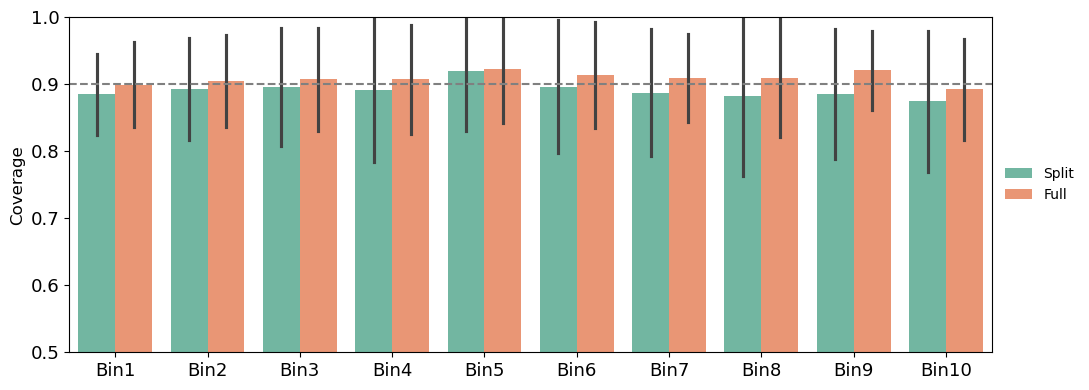

In [5]:
cv_split_bin = df[(df["method"] == "cv_split") & (df["shift_type"].str.startswith("Bin"))].copy()
cv_full_bin  = df[(df["method"] == "cv_full")  & (df["shift_type"].str.startswith("Bin"))].copy()

coverage_df = pd.concat([cv_split_bin, cv_full_bin], axis=0)
coverage_df['method'] = coverage_df['method'].replace({'cv_split': 'Split', 'cv_full': 'Full'})
original_palette = sns.color_palette("Set2", n_colors=2)

# plot
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(
    data=coverage_df,
    x="shift_type", y="coverage", hue="method",
    palette=original_palette, ax=ax, errorbar="sd"
)
legend = sns.move_legend(
    ax, "center left",
    bbox_to_anchor=(1, 0.5), ncol=1, title=None, frameon=False,
)
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)

ax.axhline(0.9, color='gray', linestyle='--', label="target coverage") 
ax.set_ylim(0.5, 1)
ax.set_xlabel("")
ax.set_ylabel("Coverage", fontsize=12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()

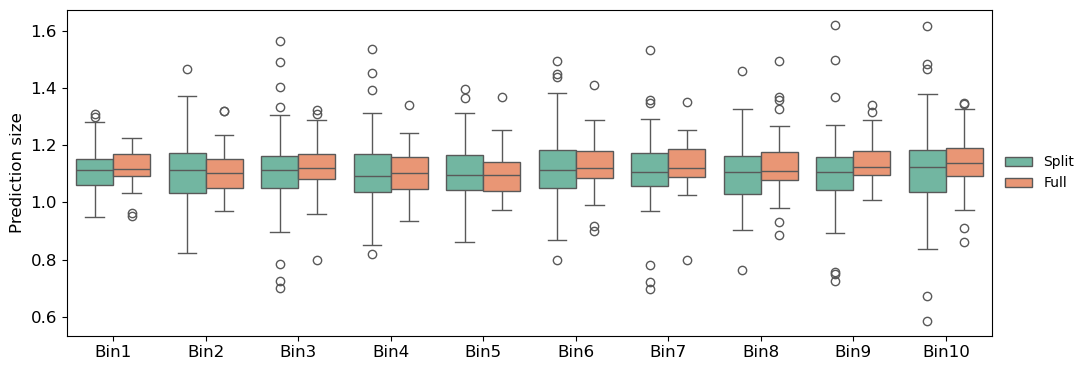

In [6]:
bin_df = coverage_df[coverage_df["shift_type"].str.startswith("Bin")].copy()
bin_df["shift_type"] = bin_df["shift_type"].astype(str)
bin_order = sorted(bin_df["shift_type"].unique(), key=lambda x: int(x.replace("Bin", "")))

fig, ax = plt.subplots(figsize=(11, 4))

sns.boxplot(
    data=bin_df,
    x="shift_type", y="cutoff", hue="method",
    palette=original_palette, ax=ax, order=bin_order,
)

legend = sns.move_legend(
    ax, "center left",
    bbox_to_anchor=(1, 0.5), ncol=1, title=None, frameon=False,
)
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)

ax.set_xlabel(" ")
ax.set_ylabel("Prediction size", fontsize=12) 
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

### We check the effect of randomization on $S$ in constructing prediction sets.

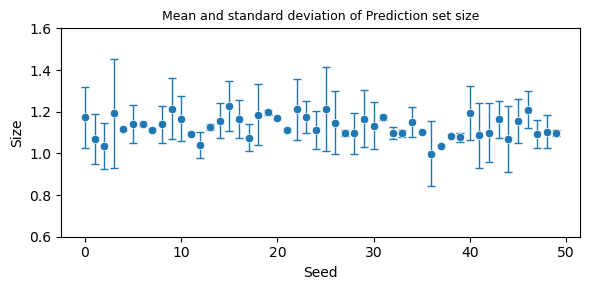

In [7]:
df_rand = df[(df['method']== 'cv_full') & (df['shift_type']== 'Marginal')]
df_rand = df_rand.copy()
df_rand['seed'] = df_rand['seed'] - 214
fig, ax = plt.subplots(figsize=(6, 3))
sns.scatterplot(
    data=df_rand,
    x="seed",
    y="cutoff",
    ax=ax,
    color="C0",
    zorder=3,
)

ax.errorbar(
    x=df_rand["seed"],
    y=df_rand["cutoff"],
    yerr=df_rand["std_cutoff"],
    fmt="none",
    ecolor="C0",
    elinewidth=1,
    capsize=3,
    zorder=2,
)

ax.set_title("Mean and standard deviation of Prediction set size", fontsize=9)
ax.set_ylim(0.6, 1.6)
ax.set_xlabel("Seed")
ax.set_ylabel("Size")
plt.tight_layout()
plt.show()

### We also check the fraction of time on hyperparmeter tuning out of the total runtime.

In [8]:
time1 = df.groupby(['seed'])['time_tune'].mean()
time2 = df.groupby(['seed'])['time_total'].mean()

/var/folders/0b/w1czghy14lgbrx9zm77dkkvw0000gn/T/ipykernel_16886/2887870139.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


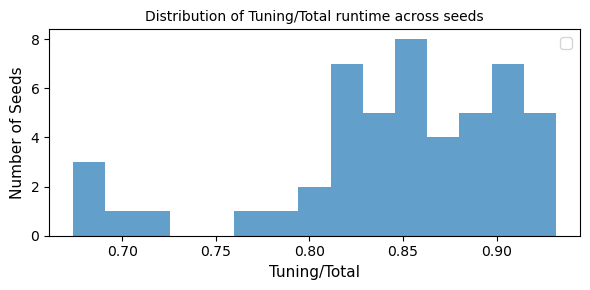

In [9]:
plt.figure(figsize=(6, 3))
plt.hist(time1/time2, bins=15, alpha=0.7)
plt.xlabel("Tuning/Total", fontsize=11)
plt.ylabel("Number of Seeds", fontsize=11)
plt.title("Distribution of Tuning/Total runtime across seeds", fontsize=10)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()